### Importing Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

## Match Summary



### Importing Match Summary (JSON)

In [9]:
with open('D:/Alina/DA Projects/Cricket Analysis/t20_json_files/t20_wc_match_results.json') as f:
    data = json.load(f)
data

[{'matchSummary': [{'team1': 'Namibia',
    'team2': 'Sri Lanka',
    'winner': 'Namibia',
    'margin': '55 runs',
    'ground': 'Geelong',
    'matchDate': 'Oct 16, 2022',
    'scorecard': 'T20I # 1823'},
   {'team1': 'Netherlands',
    'team2': 'U.A.E.',
    'winner': 'Netherlands',
    'margin': '3 wickets',
    'ground': 'Geelong',
    'matchDate': 'Oct 16, 2022',
    'scorecard': 'T20I # 1825'},
   {'team1': 'Scotland',
    'team2': 'West Indies',
    'winner': 'Scotland',
    'margin': '42 runs',
    'ground': 'Hobart',
    'matchDate': 'Oct 17, 2022',
    'scorecard': 'T20I # 1826'},
   {'team1': 'Ireland',
    'team2': 'Zimbabwe',
    'winner': 'Zimbabwe',
    'margin': '31 runs',
    'ground': 'Hobart',
    'matchDate': 'Oct 17, 2022',
    'scorecard': 'T20I # 1828'},
   {'team1': 'Namibia',
    'team2': 'Netherlands',
    'winner': 'Netherlands',
    'margin': '5 wickets',
    'ground': 'Geelong',
    'matchDate': 'Oct 18, 2022',
    'scorecard': 'T20I # 1830'},
   {'team1':

### Creating DataFrame

In [10]:
df_match = pd.DataFrame(data[0]['matchSummary'])
df_match.head()

,team1,team2,winner,margin,ground,matchDate,scorecard
0,Namibia,Sri Lanka,Namibia,55 runs,Geelong,"Oct 16, 2022",T20I # 1823
1,Netherlands,U.A.E.,Netherlands,3 wickets,Geelong,"Oct 16, 2022",T20I # 1825
2,Scotland,West Indies,Scotland,42 runs,Hobart,"Oct 17, 2022",T20I # 1826
3,Ireland,Zimbabwe,Zimbabwe,31 runs,Hobart,"Oct 17, 2022",T20I # 1828
4,Namibia,Netherlands,Netherlands,5 wickets,Geelong,"Oct 18, 2022",T20I # 1830


### Exploratory Data Checks

In [11]:
df_match.shape

(45, 7)

In [13]:
df_match.duplicated().sum()

np.int64(0)

In [14]:
df_match.isnull().sum()

team1        0
team2        0
winner       0
margin       0
ground       0
matchDate    0
scorecard    0
dtype: int64

### Data Transformation

In [16]:
df_match.rename({"scorecard" : "match_id"}, axis = 1, inplace = True)
df_match.head()

,team1,team2,winner,margin,ground,matchDate,match_id
0,Namibia,Sri Lanka,Namibia,55 runs,Geelong,"Oct 16, 2022",T20I # 1823
1,Netherlands,U.A.E.,Netherlands,3 wickets,Geelong,"Oct 16, 2022",T20I # 1825
2,Scotland,West Indies,Scotland,42 runs,Hobart,"Oct 17, 2022",T20I # 1826
3,Ireland,Zimbabwe,Zimbabwe,31 runs,Hobart,"Oct 17, 2022",T20I # 1828
4,Namibia,Netherlands,Netherlands,5 wickets,Geelong,"Oct 18, 2022",T20I # 1830


In [29]:
df_match['matchDate'] = pd.to_datetime(df_match['matchDate'])
df_match.head()

,team1,team2,winner,margin,ground,matchDate,match_id,stage
0,Namibia,Sri Lanka,Namibia,55 runs,Geelong,2022-10-16,T20I # 1823,Qualifier
1,Netherlands,U.A.E.,Netherlands,3 wickets,Geelong,2022-10-16,T20I # 1825,Qualifier
2,Scotland,West Indies,Scotland,42 runs,Hobart,2022-10-17,T20I # 1826,Qualifier
3,Ireland,Zimbabwe,Zimbabwe,31 runs,Hobart,2022-10-17,T20I # 1828,Qualifier
4,Namibia,Netherlands,Netherlands,5 wickets,Geelong,2022-10-18,T20I # 1830,Qualifier


In [30]:
df_match['stage'] = np.where(df_match['matchDate'] < '2022-10-22', 'Qualifier', 'Super12')
df_match.head(15)

,team1,team2,winner,margin,ground,matchDate,match_id,stage
0,Namibia,Sri Lanka,Namibia,55 runs,Geelong,2022-10-16,T20I # 1823,Qualifier
1,Netherlands,U.A.E.,Netherlands,3 wickets,Geelong,2022-10-16,T20I # 1825,Qualifier
2,Scotland,West Indies,Scotland,42 runs,Hobart,2022-10-17,T20I # 1826,Qualifier
3,Ireland,Zimbabwe,Zimbabwe,31 runs,Hobart,2022-10-17,T20I # 1828,Qualifier
4,Namibia,Netherlands,Netherlands,5 wickets,Geelong,2022-10-18,T20I # 1830,Qualifier
5,Sri Lanka,U.A.E.,Sri Lanka,79 runs,Geelong,2022-10-18,T20I # 1832,Qualifier
6,Ireland,Scotland,Ireland,6 wickets,Hobart,2022-10-19,T20I # 1833,Qualifier
7,West Indies,Zimbabwe,West Indies,31 runs,Hobart,2022-10-19,T20I # 1834,Qualifier
8,Netherlands,Sri Lanka,Sri Lanka,16 runs,Geelong,2022-10-20,T20I # 1835,Qualifier
9,Namibia,U.A.E.,U.A.E.,7 runs,Geelong,2022-10-20,T20I # 1836,Qualifier


### Exporting Match Summary (CSV)

In [31]:
df_match.to_csv("D:/Alina/DA Projects/Cricket Analysis//matchsummary.csv", index=False)

## Batting Summary

### Importing Batting Summary (JSON)

In [52]:
with open('D:/Alina/DA Projects/Cricket Analysis/t20_json_files/t20_wc_batting_summary.json') as f:
    data = json.load(f)
data

[{'battingSummary': [{'match': 'Namibia Vs Sri Lanka',
    'teamInnings': 'Namibia',
    'battingPos': 1,
    'batsmanName': 'Michael van Lingen',
    'dismissal': 'c Pramod Madushan b Chameera',
    'runs': '3',
    'balls': '6',
    '4s': '0',
    '6s': '0',
    'SR': '50.00'},
   {'match': 'Namibia Vs Sri Lanka',
    'teamInnings': 'Namibia',
    'battingPos': 2,
    'batsmanName': 'Divan la Cock',
    'dismissal': 'c Shanaka b Pramod Madushan',
    'runs': '9',
    'balls': '9',
    '4s': '1',
    '6s': '0',
    'SR': '100.00'},
   {'match': 'Namibia Vs Sri Lanka',
    'teamInnings': 'Namibia',
    'battingPos': 3,
    'batsmanName': 'Jan Nicol Loftie-Eaton',
    'dismissal': 'c â€\xa0Mendis b Karunaratne',
    'runs': '20',
    'balls': '12',
    '4s': '1',
    '6s': '2',
    'SR': '166.66'},
   {'match': 'Namibia Vs Sri Lanka',
    'teamInnings': 'Namibia',
    'battingPos': 4,
    'batsmanName': 'Stephan Baard',
    'dismissal': 'c DM de Silva b Pramod Madushan',
    'runs': '26

### Combining all Batting Summary into a single dict

In [53]:
all_records = []
for rec in data:
    all_records.extend(rec['battingSummary'])
all_records

[{'match': 'Namibia Vs Sri Lanka',
  'teamInnings': 'Namibia',
  'battingPos': 1,
  'batsmanName': 'Michael van Lingen',
  'dismissal': 'c Pramod Madushan b Chameera',
  'runs': '3',
  'balls': '6',
  '4s': '0',
  '6s': '0',
  'SR': '50.00'},
 {'match': 'Namibia Vs Sri Lanka',
  'teamInnings': 'Namibia',
  'battingPos': 2,
  'batsmanName': 'Divan la Cock',
  'dismissal': 'c Shanaka b Pramod Madushan',
  'runs': '9',
  'balls': '9',
  '4s': '1',
  '6s': '0',
  'SR': '100.00'},
 {'match': 'Namibia Vs Sri Lanka',
  'teamInnings': 'Namibia',
  'battingPos': 3,
  'batsmanName': 'Jan Nicol Loftie-Eaton',
  'dismissal': 'c â€\xa0Mendis b Karunaratne',
  'runs': '20',
  'balls': '12',
  '4s': '1',
  '6s': '2',
  'SR': '166.66'},
 {'match': 'Namibia Vs Sri Lanka',
  'teamInnings': 'Namibia',
  'battingPos': 4,
  'batsmanName': 'Stephan Baard',
  'dismissal': 'c DM de Silva b Pramod Madushan',
  'runs': '26',
  'balls': '24',
  '4s': '2',
  '6s': '0',
  'SR': '108.33'},
 {'match': 'Namibia Vs Sr

### Creating DataFrame

In [54]:
df_batting = pd.DataFrame(all_records)
df_batting.head()

,match,teamInnings,battingPos,batsmanName,dismissal,runs,balls,4s,6s,SR
0,Namibia Vs Sri Lanka,Namibia,1,Michael van Lingen,c Pramod Madushan b Chameera,3,6,0,0,50.00
1,Namibia Vs Sri Lanka,Namibia,2,Divan la Cock,c Shanaka b Pramod Madushan,9,9,1,0,100.00
2,Namibia Vs Sri Lanka,Namibia,3,Jan Nicol Loftie-Eaton,c â€ Mendis b Karunaratne,20,12,1,2,166.66
3,Namibia Vs Sri Lanka,Namibia,4,Stephan Baard,c DM de Silva b Pramod Madushan,26,24,2,0,108.33
4,Namibia Vs Sri Lanka,Namibia,5,Gerhard Erasmus(c),c Gunathilaka b PWH de Silva,20,24,0,0,83.33


In [55]:
df_batting.tail()

,match,teamInnings,battingPos,batsmanName,dismissal,runs,balls,4s,6s,SR
694,Pakistan Vs England,England,3,Phil Salt,c Iftikhar Ahmed b Haris Rauf,10,9,2,0,111.11
695,Pakistan Vs England,England,4,Ben Stokes,,52,49,5,1,106.12
696,Pakistan Vs England,England,5,Harry Brook,c Shaheen Shah Afridi b Shadab Khan,20,23,1,0,86.95
697,Pakistan Vs England,England,6,Moeen Ali,b Mohammad Wasim,19,13,3,0,146.15
698,Pakistan Vs England,England,7,Liam Livingstone,,1,1,0,0,100.00


### Exploratory Data Checks

In [38]:
df_batting.shape

(699, 10)

In [39]:
df_batting.duplicated().sum()

np.int64(0)

In [40]:
df_batting.isnull().sum()

match          0
teamInnings    0
battingPos     0
batsmanName    0
dismissal      0
runs           0
balls          0
4s             0
6s             0
SR             0
dtype: int64

In [42]:
df_batting.dtypes

match          object
teamInnings    object
battingPos      int64
batsmanName    object
dismissal      object
runs           object
balls          object
4s             object
6s             object
SR             object
dtype: object

## Data Transformation

### Out/NotOut Column Based On Dismissal

In [70]:
df_batting["out"] = df_batting.dismissal.apply(lambda x: "1" if len(x) > 0 else "0")
df_batting.head(11)

,match,teamInnings,battingPos,batsmanName,dismissal,runs,balls,4s,6s,SR,out/not_out,out
0,Namibia Vs Sri Lanka,Namibia,1,Michael van Lingen,c Pramod Madushan b Chameera,3,6,0,0,50.00,1,1
1,Namibia Vs Sri Lanka,Namibia,2,Divan la Cock,c Shanaka b Pramod Madushan,9,9,1,0,100.00,1,1
2,Namibia Vs Sri Lanka,Namibia,3,Jan Nicol Loftie-Eaton,c â€ Mendis b Karunaratne,20,12,1,2,166.66,1,1
3,Namibia Vs Sri Lanka,Namibia,4,Stephan Baard,c DM de Silva b Pramod Madushan,26,24,2,0,108.33,1,1
4,Namibia Vs Sri Lanka,Namibia,5,Gerhard Erasmus(c),c Gunathilaka b PWH de Silva,20,24,0,0,83.33,1,1
5,Namibia Vs Sri Lanka,Namibia,6,Jan Frylinck,run out (Gunathilaka/â€ Mendis),44,28,4,0,157.14,1,1
6,Namibia Vs Sri Lanka,Namibia,7,David Wiese,c â€ Mendis b Theekshana,0,1,0,0,0.00,1,1
7,Namibia Vs Sri Lanka,Namibia,8,JJ Smit,,31,16,2,2,193.75,0,0
8,Namibia Vs Sri Lanka,Sri Lanka,1,Pathum Nissanka,c Smit b Shikongo,9,10,1,0,90.00,1,1
9,Namibia Vs Sri Lanka,Sri Lanka,2,Kusal Mendisâ€,c â€ Green b Wiese,6,6,0,0,100.00,1,1


In [66]:
df_batting.tail(25)

,match,teamInnings,battingPos,batsmanName,dismissal,runs,balls,4s,6s,SR,out/not_out,out
674,India Vs England,India,2,Rohit Sharma(c),c Curran b Jordan,27,28,4,0,96.42,1,1
675,India Vs England,India,3,Virat Kohli,c Rashid b Jordan,50,40,4,1,125.00,1,1
676,India Vs England,India,4,Suryakumar Yadav,c Salt b Rashid,14,10,1,1,140.00,1,1
677,India Vs England,India,5,Hardik Pandya,hit wicket b Jordan,63,33,4,5,190.90,1,1
678,India Vs England,India,6,Rishabh Pantâ€,run out (â€ Buttler/Jordan),6,4,1,0,150.00,1,1
679,India Vs England,India,7,Ravichandran Ashwin,,0,0,0,0,0.00,0,0
680,India Vs England,England,1,Jos Buttler(c)â€,,80,49,9,3,163.26,0,0
681,India Vs England,England,2,Alex Hales,,86,47,4,7,182.97,0,0
682,Pakistan Vs England,Pakistan,1,Mohammad Rizwanâ€,b Curran,15,14,0,1,107.14,1,1
683,Pakistan Vs England,Pakistan,2,Babar Azam(c),c & b Rashid,32,28,2,0,114.28,1,1


### Replacing - in SR Column with 0

In [67]:
df_batting['SR'] = df_batting['SR'].replace('-', 0)
df_batting.tail(25)

,match,teamInnings,battingPos,batsmanName,dismissal,runs,balls,4s,6s,SR,out/not_out,out
674,India Vs England,India,2,Rohit Sharma(c),c Curran b Jordan,27,28,4,0,96.42,1,1
675,India Vs England,India,3,Virat Kohli,c Rashid b Jordan,50,40,4,1,125.00,1,1
676,India Vs England,India,4,Suryakumar Yadav,c Salt b Rashid,14,10,1,1,140.00,1,1
677,India Vs England,India,5,Hardik Pandya,hit wicket b Jordan,63,33,4,5,190.90,1,1
678,India Vs England,India,6,Rishabh Pantâ€,run out (â€ Buttler/Jordan),6,4,1,0,150.00,1,1
679,India Vs England,India,7,Ravichandran Ashwin,,0,0,0,0,0.00,0,0
680,India Vs England,England,1,Jos Buttler(c)â€,,80,49,9,3,163.26,0,0
681,India Vs England,England,2,Alex Hales,,86,47,4,7,182.97,0,0
682,Pakistan Vs England,Pakistan,1,Mohammad Rizwanâ€,b Curran,15,14,0,1,107.14,1,1
683,Pakistan Vs England,Pakistan,2,Babar Azam(c),c & b Rashid,32,28,2,0,114.28,1,1


### Changing Data Types of Numeric Columns

In [63]:
df_batting = df_batting.astype({
    'runs': 'int',
    'balls': 'int',
    '4s': 'int',
    '6s': 'int',
    'SR': 'float',
    'out': 'int'
})

In [68]:
df_batting.dtypes

match           object
teamInnings     object
battingPos       int64
batsmanName     object
dismissal       object
runs             int64
balls            int64
4s               int64
6s               int64
SR             float64
out/not_out     object
out              int64
dtype: object

In [69]:
df_batting.head()

,match,teamInnings,battingPos,batsmanName,dismissal,runs,balls,4s,6s,SR,out/not_out,out
0,Namibia Vs Sri Lanka,Namibia,1,Michael van Lingen,c Pramod Madushan b Chameera,3,6,0,0,50.00,1,1
1,Namibia Vs Sri Lanka,Namibia,2,Divan la Cock,c Shanaka b Pramod Madushan,9,9,1,0,100.00,1,1
2,Namibia Vs Sri Lanka,Namibia,3,Jan Nicol Loftie-Eaton,c â€ Mendis b Karunaratne,20,12,1,2,166.66,1,1
3,Namibia Vs Sri Lanka,Namibia,4,Stephan Baard,c DM de Silva b Pramod Madushan,26,24,2,0,108.33,1,1
4,Namibia Vs Sri Lanka,Namibia,5,Gerhard Erasmus(c),c Gunathilaka b PWH de Silva,20,24,0,0,83.33,1,1


### Dropping Unnecessary Columns

In [71]:
df_batting.drop(columns=["dismissal"], inplace = True)
df_batting.head(10)

,match,teamInnings,battingPos,batsmanName,runs,balls,4s,6s,SR,out/not_out,out
0,Namibia Vs Sri Lanka,Namibia,1,Michael van Lingen,3,6,0,0,50.00,1,1
1,Namibia Vs Sri Lanka,Namibia,2,Divan la Cock,9,9,1,0,100.00,1,1
2,Namibia Vs Sri Lanka,Namibia,3,Jan Nicol Loftie-Eaton,20,12,1,2,166.66,1,1
3,Namibia Vs Sri Lanka,Namibia,4,Stephan Baard,26,24,2,0,108.33,1,1
4,Namibia Vs Sri Lanka,Namibia,5,Gerhard Erasmus(c),20,24,0,0,83.33,1,1
5,Namibia Vs Sri Lanka,Namibia,6,Jan Frylinck,44,28,4,0,157.14,1,1
6,Namibia Vs Sri Lanka,Namibia,7,David Wiese,0,1,0,0,0.00,1,1
7,Namibia Vs Sri Lanka,Namibia,8,JJ Smit,31,16,2,2,193.75,0,0
8,Namibia Vs Sri Lanka,Sri Lanka,1,Pathum Nissanka,9,10,1,0,90.00,1,1
9,Namibia Vs Sri Lanka,Sri Lanka,2,Kusal Mendisâ€,6,6,0,0,100.00,1,1


In [72]:
df_batting.drop(columns=["out/not_out"], inplace = True)
df_batting.head(10)

,match,teamInnings,battingPos,batsmanName,runs,balls,4s,6s,SR,out
0,Namibia Vs Sri Lanka,Namibia,1,Michael van Lingen,3,6,0,0,50.00,1
1,Namibia Vs Sri Lanka,Namibia,2,Divan la Cock,9,9,1,0,100.00,1
2,Namibia Vs Sri Lanka,Namibia,3,Jan Nicol Loftie-Eaton,20,12,1,2,166.66,1
3,Namibia Vs Sri Lanka,Namibia,4,Stephan Baard,26,24,2,0,108.33,1
4,Namibia Vs Sri Lanka,Namibia,5,Gerhard Erasmus(c),20,24,0,0,83.33,1
5,Namibia Vs Sri Lanka,Namibia,6,Jan Frylinck,44,28,4,0,157.14,1
6,Namibia Vs Sri Lanka,Namibia,7,David Wiese,0,1,0,0,0.00,1
7,Namibia Vs Sri Lanka,Namibia,8,JJ Smit,31,16,2,2,193.75,0
8,Namibia Vs Sri Lanka,Sri Lanka,1,Pathum Nissanka,9,10,1,0,90.00,1
9,Namibia Vs Sri Lanka,Sri Lanka,2,Kusal Mendisâ€,6,6,0,0,100.00,1


### Removing Special Characters from Batsman Name

In [73]:
df_batting[df_batting['batsmanName'].str.contains(r'[^a-zA-Z0-9 ]', regex=True)]

,match,teamInnings,battingPos,batsmanName,runs,balls,4s,6s,SR,out
2,Namibia Vs Sri Lanka,Namibia,3,Jan Nicol Loftie-Eaton,20,12,1,2,166.66,1
4,Namibia Vs Sri Lanka,Namibia,5,Gerhard Erasmus(c),20,24,0,0,83.33,1
9,Namibia Vs Sri Lanka,Sri Lanka,2,Kusal Mendisâ€,6,6,0,0,100.00,1
13,Namibia Vs Sri Lanka,Sri Lanka,6,Dasun Shanaka(c),29,23,2,1,126.08,1
22,U.A.E. Vs Netherlands,U.A.E.,4,Vriitya Aravindâ€,18,21,0,0,85.71,1
...,...,...,...,...,...,...,...,...,...,...
678,India Vs England,India,6,Rishabh Pantâ€,6,4,1,0,150.00,1
680,India Vs England,England,1,Jos Buttler(c)â€,80,49,9,3,163.26,0
682,Pakistan Vs England,Pakistan,1,Mohammad Rizwanâ€,15,14,0,1,107.14,1
683,Pakistan Vs England,Pakistan,2,Babar Azam(c),32,28,2,0,114.28,1


In [74]:
df_batting["batsmanName"] = df_batting["batsmanName"].str.replace(r"[!#$^&@*%â€\xa0]", "", regex=True)
df_batting.head(25)

,match,teamInnings,battingPos,batsmanName,runs,balls,4s,6s,SR,out
0,Namibia Vs Sri Lanka,Namibia,1,Michael van Lingen,3,6,0,0,50.00,1
1,Namibia Vs Sri Lanka,Namibia,2,Divan la Cock,9,9,1,0,100.00,1
2,Namibia Vs Sri Lanka,Namibia,3,Jan Nicol Loftie-Eaton,20,12,1,2,166.66,1
3,Namibia Vs Sri Lanka,Namibia,4,Stephan Baard,26,24,2,0,108.33,1
4,Namibia Vs Sri Lanka,Namibia,5,Gerhard Erasmus(c),20,24,0,0,83.33,1
5,Namibia Vs Sri Lanka,Namibia,6,Jan Frylinck,44,28,4,0,157.14,1
6,Namibia Vs Sri Lanka,Namibia,7,David Wiese,0,1,0,0,0.00,1
7,Namibia Vs Sri Lanka,Namibia,8,JJ Smit,31,16,2,2,193.75,0
8,Namibia Vs Sri Lanka,Sri Lanka,1,Pathum Nissanka,9,10,1,0,90.00,1
9,Namibia Vs Sri Lanka,Sri Lanka,2,Kusal Mendis,6,6,0,0,100.00,1


### Joining match_id with Batting Summary

In [75]:
match_ids_dict = {}
for index, row in df_match.iterrows():
    key1 = row['team1'] + ' Vs ' + row['team2']
    key2 = row['team2'] + ' Vs ' + row['team1']

    match_ids_dict[key1] = row["match_id"]
    match_ids_dict[key2] = row["match_id"]
match_ids_dict

{'Namibia Vs Sri Lanka': 'T20I # 1823',
 'Sri Lanka Vs Namibia': 'T20I # 1823',
 'Netherlands Vs U.A.E.': 'T20I # 1825',
 'U.A.E. Vs Netherlands': 'T20I # 1825',
 'Scotland Vs West Indies': 'T20I # 1826',
 'West Indies Vs Scotland': 'T20I # 1826',
 'Ireland Vs Zimbabwe': 'T20I # 1828',
 'Zimbabwe Vs Ireland': 'T20I # 1828',
 'Namibia Vs Netherlands': 'T20I # 1830',
 'Netherlands Vs Namibia': 'T20I # 1830',
 'Sri Lanka Vs U.A.E.': 'T20I # 1832',
 'U.A.E. Vs Sri Lanka': 'T20I # 1832',
 'Ireland Vs Scotland': 'T20I # 1833',
 'Scotland Vs Ireland': 'T20I # 1833',
 'West Indies Vs Zimbabwe': 'T20I # 1834',
 'Zimbabwe Vs West Indies': 'T20I # 1834',
 'Netherlands Vs Sri Lanka': 'T20I # 1835',
 'Sri Lanka Vs Netherlands': 'T20I # 1835',
 'Namibia Vs U.A.E.': 'T20I # 1836',
 'U.A.E. Vs Namibia': 'T20I # 1836',
 'Ireland Vs West Indies': 'T20I # 1837',
 'West Indies Vs Ireland': 'T20I # 1837',
 'Scotland Vs Zimbabwe': 'T20I # 1838',
 'Zimbabwe Vs Scotland': 'T20I # 1838',
 'Australia Vs New Zea

In [76]:
df_batting["match_id"] = df_batting["match"].map(match_ids_dict)
df_batting.head(30)

,match,teamInnings,battingPos,batsmanName,runs,balls,4s,6s,SR,out,match_id
0,Namibia Vs Sri Lanka,Namibia,1,Michael van Lingen,3,6,0,0,50.00,1,T20I # 1823
1,Namibia Vs Sri Lanka,Namibia,2,Divan la Cock,9,9,1,0,100.00,1,T20I # 1823
2,Namibia Vs Sri Lanka,Namibia,3,Jan Nicol Loftie-Eaton,20,12,1,2,166.66,1,T20I # 1823
3,Namibia Vs Sri Lanka,Namibia,4,Stephan Baard,26,24,2,0,108.33,1,T20I # 1823
4,Namibia Vs Sri Lanka,Namibia,5,Gerhard Erasmus(c),20,24,0,0,83.33,1,T20I # 1823
5,Namibia Vs Sri Lanka,Namibia,6,Jan Frylinck,44,28,4,0,157.14,1,T20I # 1823
6,Namibia Vs Sri Lanka,Namibia,7,David Wiese,0,1,0,0,0.00,1,T20I # 1823
7,Namibia Vs Sri Lanka,Namibia,8,JJ Smit,31,16,2,2,193.75,0,T20I # 1823
8,Namibia Vs Sri Lanka,Sri Lanka,1,Pathum Nissanka,9,10,1,0,90.00,1,T20I # 1823
9,Namibia Vs Sri Lanka,Sri Lanka,2,Kusal Mendis,6,6,0,0,100.00,1,T20I # 1823


### Creating Total Runs Column

In [86]:
df_batting['total_runs'] = df_batting.groupby('batsmanName')['runs'].transform('sum')
df_batting.head()

,match,teamInnings,battingPos,batsmanName,runs,balls,4s,6s,SR,out,match_id,total_runs
0,Namibia Vs Sri Lanka,Namibia,1,Michael van Lingen,3,6,0,0,50.00,1,T20I # 1823,33
1,Namibia Vs Sri Lanka,Namibia,2,Divan la Cock,9,9,1,0,100.00,1,T20I # 1823,9
2,Namibia Vs Sri Lanka,Namibia,3,Jan Nicol Loftie-Eaton,20,12,1,2,166.66,1,T20I # 1823,21
3,Namibia Vs Sri Lanka,Namibia,4,Stephan Baard,26,24,2,0,108.33,1,T20I # 1823,49
4,Namibia Vs Sri Lanka,Namibia,5,Gerhard Erasmus(c),20,24,0,0,83.33,1,T20I # 1823,52


### Plotting Top 5 Run Scorers

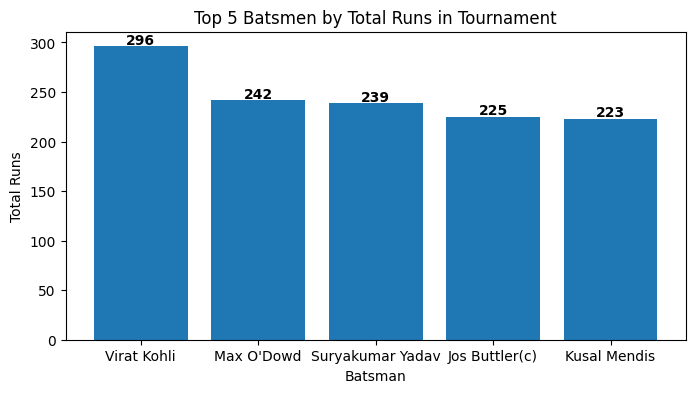

In [99]:
top5_runs = (
    df_batting.groupby('batsmanName', as_index=False)['runs']
    .sum()
    .sort_values(by='runs', ascending=False)
    .head(5)
)
# Plot bar chart
plt.figure(figsize=(8,4))
plt.bar(top5_runs['batsmanName'], top5_runs['runs'])
plt.xlabel("Batsman")
plt.ylabel("Total Runs")
plt.title("Top 5 Batsmen by Total Runs in Tournament")
# Add values on top of bars
for i, v in enumerate(top5_runs['runs']):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.show()

### Exporting Batting Summary (CSV)

In [100]:
df_batting.to_csv("D:/Alina/DA Projects/Cricket Analysis/battingsummary.csv", index=False)

## Bowling Summary

### Importing Bowling Summary (JSON)

In [146]:
with open('D:/Alina/DA Projects/Cricket Analysis/t20_json_files/t20_wc_bowling_summary.json') as f:
    data = json.load(f)

    records = []
    for rec in data:
        records.extend(rec['bowlingSummary'])
records

[{'match': 'Namibia Vs Sri Lanka',
  'bowlingTeam': 'Sri Lanka',
  'bowlerName': 'Maheesh Theekshana',
  'overs': '4',
  'maiden': '0',
  'runs': '23',
  'wickets': '1',
  'economy': '5.75',
  '0s': '7',
  '4s': '0',
  '6s': '0',
  'wides': '2',
  'noBalls': '0'},
 {'match': 'Namibia Vs Sri Lanka',
  'bowlingTeam': 'Sri Lanka',
  'bowlerName': 'Dushmantha Chameera',
  'overs': '4',
  'maiden': '0',
  'runs': '39',
  'wickets': '1',
  'economy': '9.75',
  '0s': '6',
  '4s': '3',
  '6s': '1',
  'wides': '2',
  'noBalls': '0'},
 {'match': 'Namibia Vs Sri Lanka',
  'bowlingTeam': 'Sri Lanka',
  'bowlerName': 'Pramod Madushan',
  'overs': '4',
  'maiden': '0',
  'runs': '37',
  'wickets': '2',
  'economy': '9.25',
  '0s': '6',
  '4s': '3',
  '6s': '1',
  'wides': '0',
  'noBalls': '0'},
 {'match': 'Namibia Vs Sri Lanka',
  'bowlingTeam': 'Sri Lanka',
  'bowlerName': 'Chamika Karunaratne',
  'overs': '4',
  'maiden': '0',
  'runs': '36',
  'wickets': '1',
  'economy': '9.00',
  '0s': '7',
  

### Creating DataFrame

In [147]:
df_bowling = pd.DataFrame(records)
df_bowling.head(20)

,match,bowlingTeam,bowlerName,overs,maiden,runs,wickets,economy,0s,4s,6s,wides,noBalls
0,Namibia Vs Sri Lanka,Sri Lanka,Maheesh Theekshana,4,0,23,1,5.75,7,0,0,2,0
1,Namibia Vs Sri Lanka,Sri Lanka,Dushmantha Chameera,4,0,39,1,9.75,6,3,1,2,0
2,Namibia Vs Sri Lanka,Sri Lanka,Pramod Madushan,4,0,37,2,9.25,6,3,1,0,0
3,Namibia Vs Sri Lanka,Sri Lanka,Chamika Karunaratne,4,0,36,1,9.00,7,3,1,1,0
4,Namibia Vs Sri Lanka,Sri Lanka,Wanindu Hasaranga de Silva,4,0,27,1,6.75,8,1,1,0,0
5,Namibia Vs Sri Lanka,Namibia,Gerhard Erasmus,1,0,8,0,8.00,1,1,0,0,0
6,Namibia Vs Sri Lanka,Namibia,David Wiese,4,0,16,2,4.00,13,1,0,0,0
7,Namibia Vs Sri Lanka,Namibia,Bernard Scholtz,4,0,18,2,4.50,10,1,0,0,0
8,Namibia Vs Sri Lanka,Namibia,Ben Shikongo,3,1,22,2,7.33,6,3,0,0,0
9,Namibia Vs Sri Lanka,Namibia,JJ Smit,3,0,16,1,5.33,7,0,0,1,0


In [148]:
df_bowling.tail(20)

,match,bowlingTeam,bowlerName,overs,maiden,runs,wickets,economy,0s,4s,6s,wides,noBalls
480,India Vs England,England,Liam Livingstone,3,0,21,0,7.00,7,3,0,0,0
481,India Vs England,England,Chris Jordan,4,0,43,3,10.75,8,3,3,1,0
482,India Vs England,India,Bhuvneshwar Kumar,2,0,25,0,12.50,4,3,1,1,0
483,India Vs England,India,Arshdeep Singh,2,0,15,0,7.50,4,2,0,1,0
484,India Vs England,India,Axar Patel,4,0,30,0,7.50,10,2,2,0,0
485,India Vs England,India,Mohammed Shami,3,0,39,0,13.00,7,4,3,0,0
486,India Vs England,India,Ravichandran Ashwin,2,0,27,0,13.50,1,1,2,1,0
487,India Vs England,India,Hardik Pandya,3,0,34,0,11.33,5,1,2,0,0
488,Pakistan Vs England,England,Ben Stokes,4,0,32,1,8.00,6,1,0,2,1
489,Pakistan Vs England,England,Chris Woakes,3,0,26,0,8.66,7,2,1,2,0


### Exploratory Data Checks

In [149]:
df_bowling.shape

(500, 13)

In [150]:
df_bowling.duplicated().sum()

np.int64(0)

In [151]:
df_bowling.isnull().sum()

match          0
bowlingTeam    0
bowlerName     0
overs          0
maiden         0
runs           0
wickets        0
economy        0
0s             0
4s             0
6s             0
wides          0
noBalls        0
dtype: int64

In [152]:
df_bowling.dtypes

match          object
bowlingTeam    object
bowlerName     object
overs          object
maiden         object
runs           object
wickets        object
economy        object
0s             object
4s             object
6s             object
wides          object
noBalls        object
dtype: object

In [153]:
mask = df_bowling["bowlerName"].str.contains(r"[^a-zA-Z\s]", regex=True)
invalid = df_bowling[mask]
invalid

,match,bowlingTeam,bowlerName,overs,maiden,runs,wickets,economy,0s,4s,6s,wides,noBalls
60,Namibia Vs Netherlands,Namibia,Jan Nicol Loftie-Eaton,1,0,8,0,8.00,2,1,0,0,1
405,Australia Vs Afghanistan,Afghanistan,Naveen-ul-Haq,4,0,21,3,5.25,11,2,0,0,0


## Data Transformation

### Dividing "Overs" Column

In [154]:
df_bowling[['overs1', 'overs2']] = df_bowling['overs'].str.split('.', expand=True)
df_bowling.tail(20)

,match,bowlingTeam,bowlerName,overs,maiden,runs,wickets,economy,0s,4s,6s,wides,noBalls,overs1,overs2
480,India Vs England,England,Liam Livingstone,3,0,21,0,7.00,7,3,0,0,0,3,None
481,India Vs England,England,Chris Jordan,4,0,43,3,10.75,8,3,3,1,0,4,None
482,India Vs England,India,Bhuvneshwar Kumar,2,0,25,0,12.50,4,3,1,1,0,2,None
483,India Vs England,India,Arshdeep Singh,2,0,15,0,7.50,4,2,0,1,0,2,None
484,India Vs England,India,Axar Patel,4,0,30,0,7.50,10,2,2,0,0,4,None
485,India Vs England,India,Mohammed Shami,3,0,39,0,13.00,7,4,3,0,0,3,None
486,India Vs England,India,Ravichandran Ashwin,2,0,27,0,13.50,1,1,2,1,0,2,None
487,India Vs England,India,Hardik Pandya,3,0,34,0,11.33,5,1,2,0,0,3,None
488,Pakistan Vs England,England,Ben Stokes,4,0,32,1,8.00,6,1,0,2,1,4,None
489,Pakistan Vs England,England,Chris Woakes,3,0,26,0,8.66,7,2,1,2,0,3,None


In [155]:
df_bowling['overs2'] = df_bowling['overs2'].fillna(0)
df_bowling.tail(20)

,match,bowlingTeam,bowlerName,overs,maiden,runs,wickets,economy,0s,4s,6s,wides,noBalls,overs1,overs2
480,India Vs England,England,Liam Livingstone,3,0,21,0,7.00,7,3,0,0,0,3,0
481,India Vs England,England,Chris Jordan,4,0,43,3,10.75,8,3,3,1,0,4,0
482,India Vs England,India,Bhuvneshwar Kumar,2,0,25,0,12.50,4,3,1,1,0,2,0
483,India Vs England,India,Arshdeep Singh,2,0,15,0,7.50,4,2,0,1,0,2,0
484,India Vs England,India,Axar Patel,4,0,30,0,7.50,10,2,2,0,0,4,0
485,India Vs England,India,Mohammed Shami,3,0,39,0,13.00,7,4,3,0,0,3,0
486,India Vs England,India,Ravichandran Ashwin,2,0,27,0,13.50,1,1,2,1,0,2,0
487,India Vs England,India,Hardik Pandya,3,0,34,0,11.33,5,1,2,0,0,3,0
488,Pakistan Vs England,England,Ben Stokes,4,0,32,1,8.00,6,1,0,2,1,4,0
489,Pakistan Vs England,England,Chris Woakes,3,0,26,0,8.66,7,2,1,2,0,3,0


### Changing Data Types

In [158]:
df_bowling = df_bowling.astype({
    'maiden': 'int', 
    'runs': 'int',
    'wickets': 'int',
    'economy': 'float',
    '0s': 'int',
    '4s': 'int',
    '6s': 'int',
    'wides' : 'int',
    'noBalls': 'int',
    'overs1' : 'int',
    'overs2' : 'int'
})

df_bowling.dtypes

match           object
bowlingTeam     object
bowlerName      object
overs           object
maiden           int64
runs             int64
wickets          int64
economy        float64
0s               int64
4s               int64
6s               int64
wides            int64
noBalls          int64
overs1           int64
overs2           int64
dtype: object

### Creating Total Balls Bowled Column

In [162]:
df_bowling['balls'] = df_bowling['overs1']*6 + df_bowling['overs2']
df_bowling.tail(20)

,match,bowlingTeam,bowlerName,overs,maiden,runs,wickets,economy,0s,4s,6s,wides,noBalls,overs1,overs2,balls
480,India Vs England,England,Liam Livingstone,3,0,21,0,7.00,7,3,0,0,0,3,0,18
481,India Vs England,England,Chris Jordan,4,0,43,3,10.75,8,3,3,1,0,4,0,24
482,India Vs England,India,Bhuvneshwar Kumar,2,0,25,0,12.50,4,3,1,1,0,2,0,12
483,India Vs England,India,Arshdeep Singh,2,0,15,0,7.50,4,2,0,1,0,2,0,12
484,India Vs England,India,Axar Patel,4,0,30,0,7.50,10,2,2,0,0,4,0,24
485,India Vs England,India,Mohammed Shami,3,0,39,0,13.00,7,4,3,0,0,3,0,18
486,India Vs England,India,Ravichandran Ashwin,2,0,27,0,13.50,1,1,2,1,0,2,0,12
487,India Vs England,India,Hardik Pandya,3,0,34,0,11.33,5,1,2,0,0,3,0,18
488,Pakistan Vs England,England,Ben Stokes,4,0,32,1,8.00,6,1,0,2,1,4,0,24
489,Pakistan Vs England,England,Chris Woakes,3,0,26,0,8.66,7,2,1,2,0,3,0,18


### Creating Total Wickets Column

In [164]:
df_bowling['total_wickets'] = df_bowling.groupby('bowlerName')['wickets'].transform('sum')
df_bowling.head()

,match,bowlingTeam,bowlerName,overs,maiden,runs,wickets,economy,0s,4s,6s,wides,noBalls,overs1,overs2,balls,total_wickets
0,Namibia Vs Sri Lanka,Sri Lanka,Maheesh Theekshana,4,0,23,1,5.75,7,0,0,2,0,4,0,24,9
1,Namibia Vs Sri Lanka,Sri Lanka,Dushmantha Chameera,4,0,39,1,9.75,6,3,1,2,0,4,0,24,4
2,Namibia Vs Sri Lanka,Sri Lanka,Pramod Madushan,4,0,37,2,9.25,6,3,1,0,0,4,0,24,3
3,Namibia Vs Sri Lanka,Sri Lanka,Chamika Karunaratne,4,0,36,1,9.00,7,3,1,1,0,4,0,24,3
4,Namibia Vs Sri Lanka,Sri Lanka,Wanindu Hasaranga de Silva,4,0,27,1,6.75,8,1,1,0,0,4,0,24,15


### Joining match_id with Bowling Summary

In [181]:
match_ids_dict = {}
for index, row in df_match.iterrows():
    key1 = row['team1'] + ' Vs ' + row['team2']
    key2 = row['team2'] + ' Vs ' + row['team1']

    match_ids_dict[key1] = row["match_id"]
    match_ids_dict[key2] = row["match_id"]
match_ids_dict

{'Namibia Vs Sri Lanka': 'T20I # 1823',
 'Sri Lanka Vs Namibia': 'T20I # 1823',
 'Netherlands Vs U.A.E.': 'T20I # 1825',
 'U.A.E. Vs Netherlands': 'T20I # 1825',
 'Scotland Vs West Indies': 'T20I # 1826',
 'West Indies Vs Scotland': 'T20I # 1826',
 'Ireland Vs Zimbabwe': 'T20I # 1828',
 'Zimbabwe Vs Ireland': 'T20I # 1828',
 'Namibia Vs Netherlands': 'T20I # 1830',
 'Netherlands Vs Namibia': 'T20I # 1830',
 'Sri Lanka Vs U.A.E.': 'T20I # 1832',
 'U.A.E. Vs Sri Lanka': 'T20I # 1832',
 'Ireland Vs Scotland': 'T20I # 1833',
 'Scotland Vs Ireland': 'T20I # 1833',
 'West Indies Vs Zimbabwe': 'T20I # 1834',
 'Zimbabwe Vs West Indies': 'T20I # 1834',
 'Netherlands Vs Sri Lanka': 'T20I # 1835',
 'Sri Lanka Vs Netherlands': 'T20I # 1835',
 'Namibia Vs U.A.E.': 'T20I # 1836',
 'U.A.E. Vs Namibia': 'T20I # 1836',
 'Ireland Vs West Indies': 'T20I # 1837',
 'West Indies Vs Ireland': 'T20I # 1837',
 'Scotland Vs Zimbabwe': 'T20I # 1838',
 'Zimbabwe Vs Scotland': 'T20I # 1838',
 'Australia Vs New Zea

In [182]:
df_bowling["match_id"] = df_bowling["match"].map(match_ids_dict)
df_bowling.head(30)

,match,bowlingTeam,bowlerName,maiden,runs,wickets,economy,0s,4s,6s,wides,noBalls,overs1,overs2,balls,total_wickets,match_id
0,Namibia Vs Sri Lanka,Sri Lanka,Maheesh Theekshana,0,23,1,5.75,7,0,0,2,0,4,0,24,9,T20I # 1823
1,Namibia Vs Sri Lanka,Sri Lanka,Dushmantha Chameera,0,39,1,9.75,6,3,1,2,0,4,0,24,4,T20I # 1823
2,Namibia Vs Sri Lanka,Sri Lanka,Pramod Madushan,0,37,2,9.25,6,3,1,0,0,4,0,24,3,T20I # 1823
3,Namibia Vs Sri Lanka,Sri Lanka,Chamika Karunaratne,0,36,1,9.00,7,3,1,1,0,4,0,24,3,T20I # 1823
4,Namibia Vs Sri Lanka,Sri Lanka,Wanindu Hasaranga de Silva,0,27,1,6.75,8,1,1,0,0,4,0,24,15,T20I # 1823
5,Namibia Vs Sri Lanka,Namibia,Gerhard Erasmus,0,8,0,8.00,1,1,0,0,0,1,0,6,0,T20I # 1823
6,Namibia Vs Sri Lanka,Namibia,David Wiese,0,16,2,4.00,13,1,0,0,0,4,0,24,3,T20I # 1823
7,Namibia Vs Sri Lanka,Namibia,Bernard Scholtz,0,18,2,4.50,10,1,0,0,0,4,0,24,4,T20I # 1823
8,Namibia Vs Sri Lanka,Namibia,Ben Shikongo,1,22,2,7.33,6,3,0,0,0,3,0,18,3,T20I # 1823
9,Namibia Vs Sri Lanka,Namibia,JJ Smit,0,16,1,5.33,7,0,0,1,0,3,0,18,3,T20I # 1823


### Dropping Unnecessary Columns

In [165]:
df_bowling.drop(columns=["overs"], inplace = True)
df_bowling.head(10)

,match,bowlingTeam,bowlerName,maiden,runs,wickets,economy,0s,4s,6s,wides,noBalls,overs1,overs2,balls,total_wickets
0,Namibia Vs Sri Lanka,Sri Lanka,Maheesh Theekshana,0,23,1,5.75,7,0,0,2,0,4,0,24,9
1,Namibia Vs Sri Lanka,Sri Lanka,Dushmantha Chameera,0,39,1,9.75,6,3,1,2,0,4,0,24,4
2,Namibia Vs Sri Lanka,Sri Lanka,Pramod Madushan,0,37,2,9.25,6,3,1,0,0,4,0,24,3
3,Namibia Vs Sri Lanka,Sri Lanka,Chamika Karunaratne,0,36,1,9.00,7,3,1,1,0,4,0,24,3
4,Namibia Vs Sri Lanka,Sri Lanka,Wanindu Hasaranga de Silva,0,27,1,6.75,8,1,1,0,0,4,0,24,15
5,Namibia Vs Sri Lanka,Namibia,Gerhard Erasmus,0,8,0,8.00,1,1,0,0,0,1,0,6,0
6,Namibia Vs Sri Lanka,Namibia,David Wiese,0,16,2,4.00,13,1,0,0,0,4,0,24,3
7,Namibia Vs Sri Lanka,Namibia,Bernard Scholtz,0,18,2,4.50,10,1,0,0,0,4,0,24,4
8,Namibia Vs Sri Lanka,Namibia,Ben Shikongo,1,22,2,7.33,6,3,0,0,0,3,0,18,3
9,Namibia Vs Sri Lanka,Namibia,JJ Smit,0,16,1,5.33,7,0,0,1,0,3,0,18,3


### Plotting Chart for Highest Wicket Taker

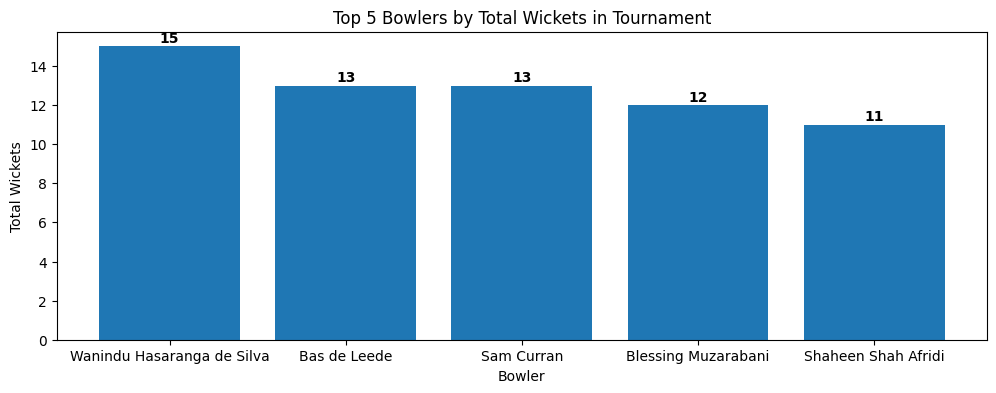

In [173]:
top5_wickets = (
    df_bowling.groupby('bowlerName', as_index=False)['wickets']
    .sum()
    .sort_values(by='wickets', ascending=False)
    .head(5)
)
# Plot bar chart
plt.figure(figsize=(12,4))
plt.bar(top5_wickets['bowlerName'], top5_wickets['wickets'])
plt.xlabel("Bowler")
plt.ylabel("Total Wickets")
plt.title("Top 5 Bowlers by Total Wickets in Tournament")
# Add values on top of bars
for i, v in enumerate(top5_wickets['wickets']):
    plt.text(i, v + 0.2, str(v), ha='center', fontweight='bold')

plt.show()

### Exporting Bowling Summary (CSV)

In [177]:
df_bowling.to_csv("D:/Alina/DA Projects/Cricket Analysis/bowlingsummary.csv", index=False)

## Player Information

### Importing Player Info (JSON)

In [178]:
with open('D:/Alina/DA Projects/Cricket Analysis/t20_json_files/t20_wc_player_info.json') as f:
    data = json.load(f)

    record = []
    for rec in data:
        record.extend(rec['playerInfo'])
record

[{'name': 'Michael van Lingen',
  'team': 'Namibia',
  'battingStyle': 'Left hand Bat',
  'bowlingStyle': 'Left arm Medium',
  'playingRole': 'Bowling Allrounder',
  'description': ''},
 {'name': 'Divan la Cock',
  'team': 'Namibia',
  'battingStyle': 'Right hand Bat',
  'bowlingStyle': 'Legbreak',
  'playingRole': 'Opening Batter',
  'description': ''},
 {'name': 'Jan Nicol Loftie-Eaton',
  'team': 'Namibia',
  'battingStyle': 'Left hand Bat',
  'bowlingStyle': 'Right arm Medium, Legbreak',
  'playingRole': 'Batter',
  'description': ''},
 {'name': 'Stephan Baard',
  'team': 'Namibia',
  'battingStyle': 'Right hand Bat',
  'bowlingStyle': 'Right arm Medium fast',
  'playingRole': 'Batter',
  'description': ''},
 {'name': 'Gerhard Erasmus(c)',
  'team': 'Namibia',
  'battingStyle': 'Right hand Bat',
  'bowlingStyle': 'Right arm Offbreak',
  'playingRole': 'Allrounder',
  'description': ''},
 {'name': 'Jan Frylinck',
  'team': 'Namibia',
  'battingStyle': 'Left hand Bat',
  'bowlingStyl

### Creating DataFrame

In [184]:
df_pinfo = pd.DataFrame(record)
df_pinfo.head(20)

,name,team,battingStyle,bowlingStyle,playingRole,description
0,Michael van Lingen,Namibia,Left hand Bat,Left arm Medium,Bowling Allrounder,
1,Divan la Cock,Namibia,Right hand Bat,Legbreak,Opening Batter,
2,Jan Nicol Loftie-Eaton,Namibia,Left hand Bat,"Right arm Medium, Legbreak",Batter,
3,Stephan Baard,Namibia,Right hand Bat,Right arm Medium fast,Batter,
4,Gerhard Erasmus(c),Namibia,Right hand Bat,Right arm Offbreak,Allrounder,
5,Jan Frylinck,Namibia,Left hand Bat,Left arm Fast medium,Allrounder,
6,David Wiese,Namibia,Right hand Bat,Right arm Medium fast,Allrounder,David Wiese joined a marked outflow of South A...
7,JJ Smit,Namibia,Right hand Bat,Left arm Medium fast,Bowling Allrounder,
8,Pathum Nissanka,Sri Lanka,Right hand Bat,,Top order Batter,
9,Kusal Mendisâ€,Sri Lanka,Right hand Bat,Legbreak,Wicketkeeper Batter,"Blessed with a compact technique, an aggressiv..."


### Exploratory Data Checks

In [186]:
df_pinfo.shape

(219, 6)

In [188]:
df_pinfo.duplicated().sum()

np.int64(0)

In [189]:
df_pinfo["name"] = df_pinfo["name"].str.replace(r"\(c\)", "", regex=True).str.strip()
df_pinfo.head()

,name,team,battingStyle,bowlingStyle,playingRole,description
0,Michael van Lingen,Namibia,Left hand Bat,Left arm Medium,Bowling Allrounder,
1,Divan la Cock,Namibia,Right hand Bat,Legbreak,Opening Batter,
2,Jan Nicol Loftie-Eaton,Namibia,Left hand Bat,"Right arm Medium, Legbreak",Batter,
3,Stephan Baard,Namibia,Right hand Bat,Right arm Medium fast,Batter,
4,Gerhard Erasmus,Namibia,Right hand Bat,Right arm Offbreak,Allrounder,


In [190]:
df_pinfo.duplicated().sum()

np.int64(6)

In [192]:
df_pinfo.isnull().sum()

name            0
team            0
battingStyle    0
bowlingStyle    0
playingRole     0
description     0
dtype: int64

## Data Transformation

### Removing Duplicates

In [194]:
df_pinfo.drop_duplicates()

,name,team,battingStyle,bowlingStyle,playingRole,description
0,Michael van Lingen,Namibia,Left hand Bat,Left arm Medium,Bowling Allrounder,
1,Divan la Cock,Namibia,Right hand Bat,Legbreak,Opening Batter,
2,Jan Nicol Loftie-Eaton,Namibia,Left hand Bat,"Right arm Medium, Legbreak",Batter,
3,Stephan Baard,Namibia,Right hand Bat,Right arm Medium fast,Batter,
4,Gerhard Erasmus,Namibia,Right hand Bat,Right arm Offbreak,Allrounder,
...,...,...,...,...,...,...
213,Wellington Masakadza,Zimbabwe,Left hand Bat,Slow Left arm Orthodox,Bowler,
214,Tabraiz Shamsi,South Africa,Right hand Bat,Left arm Wrist spin,Bowler,A left-arm wristspin bowler with ample variati...
215,Phil Salt,England,Right hand Bat,Right arm Offbreak,Wicketkeeper Batter,Phil Salt's fearless ball-striking at the top ...
216,Chris Jordan,England,Right hand Bat,Right arm Fast medium,Bowler,"Chris Jordan, a fast bowler with a level-heade..."


### Remove Special Characters from Name

In [195]:
mask = df_pinfo["name"].str.contains(r"[^a-zA-Z\s]", regex=True)
invalid = df_pinfo[mask]
invalid

,name,team,battingStyle,bowlingStyle,playingRole,description
2,Jan Nicol Loftie-Eaton,Namibia,Left hand Bat,"Right arm Medium, Legbreak",Batter,
9,Kusal Mendisâ€,Sri Lanka,Right hand Bat,Legbreak,Wicketkeeper Batter,"Blessed with a compact technique, an aggressiv..."
35,Regis Chakabvaâ€,Zimbabwe,Right hand Bat,Right arm Offbreak,Wicketkeeper Batter,"A doughty wicketkeeper-batsman, Regis Chakabva..."
45,Lorcan Tuckerâ€,Ireland,Right hand Bat,,Wicketkeeper Batter,
58,Rahmanullah Gurbazâ€,Afghanistan,Right hand Bat,,Wicketkeeper Batter,
68,Jos Buttlerâ€,England,Right hand Bat,,Wicketkeeper Batter,England have had many players down the ages wh...
81,Vriitya Aravindâ€,U.A.E.,Right hand Bat,,Wicketkeeper,
85,Zane Greenâ€,Namibia,Left hand Bat,,Wicketkeeper Batter,
96,Max O'Dowd,Netherlands,Right hand Bat,Right arm Offbreak,Opening Batter,
100,Scott Edwardsâ€,Netherlands,Right hand Bat,,Wicketkeeper Batter,


In [196]:
df_pinfo["name"] = df_pinfo["name"].str.replace(r"[â€\xa0]", "", regex=True)
df_pinfo.head(45)

,name,team,battingStyle,bowlingStyle,playingRole,description
0,Michael van Lingen,Namibia,Left hand Bat,Left arm Medium,Bowling Allrounder,
1,Divan la Cock,Namibia,Right hand Bat,Legbreak,Opening Batter,
2,Jan Nicol Loftie-Eaton,Namibia,Left hand Bat,"Right arm Medium, Legbreak",Batter,
3,Stephan Baard,Namibia,Right hand Bat,Right arm Medium fast,Batter,
4,Gerhard Erasmus,Namibia,Right hand Bat,Right arm Offbreak,Allrounder,
5,Jan Frylinck,Namibia,Left hand Bat,Left arm Fast medium,Allrounder,
6,David Wiese,Namibia,Right hand Bat,Right arm Medium fast,Allrounder,David Wiese joined a marked outflow of South A...
7,JJ Smit,Namibia,Right hand Bat,Left arm Medium fast,Bowling Allrounder,
8,Pathum Nissanka,Sri Lanka,Right hand Bat,,Top order Batter,
9,Kusal Mendis,Sri Lanka,Right hand Bat,Legbreak,Wicketkeeper Batter,"Blessed with a compact technique, an aggressiv..."


### Exporting Player Information (CSV)

In [197]:
df_pinfo.to_csv("D:/Alina/DA Projects/Cricket Analysis/playerInformation.csv", index=False)